# NYC Crime Dataset Exploratory Data Analysis (EDA)
The purpose of this notebook is to visualize the dataset and identify common trends or correlations emerging in the data to guide what patterns should be further investigated using ML approaches.

## Imports and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

#Plot Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
PALETTE = sns.color_palette('muted')

In [3]:
df = pd.read_csv('nyc_crime_data_cleaned.csv')

#Parse datetime columns
df['CMPLNT_FR_DTTM'] = pd.to_datetime(df['CMPLNT_FR_DTTM'], errors='coerce')
df['CMPLNT_TO_DTTM'] = pd.to_datetime(df['CMPLNT_TO_DTTM'], errors='coerce')
df['RPT_DT'] = pd.to_datetime(df['RPT_DT'], errors='coerce')

#Derived time features
df['HOUR'] = df['CMPLNT_FR_DTTM'].dt.hour
df['DAY_OF_WEEK'] = df['CMPLNT_FR_DTTM'].dt.day_name()
df['MONTH'] = df['CMPLNT_FR_DTTM'].dt.month
df['MONTH_NAME'] = df['CMPLNT_FR_DTTM'].dt.strftime('%b')
df['YEAR'] = df['CMPLNT_FR_DTTM'].dt.year

#Time-of-day bins
bins = [-1, 5, 11, 16, 20, 23]
labels = ['Late Night (0-5)', 'Morning (6-11)', 'Afternoon (12-16)', 'Evening (17-20)', 'Night (21-23)']
df['TIME_OF_DAY'] = pd.cut(df['HOUR'], bins=bins, labels=labels)

print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')
print(f'Date range: {df["CMPLNT_FR_DTTM"].min().date()} to {df["CMPLNT_FR_DTTM"].max().date()}')

C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\14550539.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('nyc_crime_data_cleaned.csv')


Rows: 50,000 | Columns: 38
Date range: 2017-01-02 to 2019-01-01


## Data Overview
Quick sanity check on shape, nulls, and key column distributions before diving into analysis.

In [4]:
#Shape and data types
print('Shape:', df.shape)
display(df.head(3))

Shape: (50000, 38)


,CMPLNT_NUM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_FR_DTTM,CMPLNT_TO_DT,CMPLNT_TO_TM,CMPLNT_TO_DTTM,ADDR_PCT_CD,RPT_DT,KY_CD,...,PATROL_BORO,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,HOUR,DAY_OF_WEEK,MONTH,MONTH_NAME,YEAR,TIME_OF_DAY
0,169450128,2017-09-11,16:30:00,2017-09-11 16:30:00,2017-09-13,16:45:00,2017-09-13 16:45:00,45,2017-09-17,578,...,PATROL BORO BRONX,45-64,BLACK,M,16,Monday,9,Sep,2017,Afternoon (12-16)
1,167086123,2017-07-15,21:15:00,2017-07-15 21:15:00,2017-07-15,21:25:00,2017-07-15 21:25:00,34,2017-07-15,106,...,PATROL BORO MAN NORTH,25-44,WHITE,M,21,Saturday,7,Jul,2017,Night (21-23)
2,162097170,2017-01-28,17:36:00,2017-01-28 17:36:00,NaN,NaN,NaT,20,2017-02-20,121,...,PATROL BORO MAN NORTH,UNKNOWN,UNKNOWN,E,17,Saturday,1,Jan,2017,Evening (17-20)


In [5]:
#Null summary for key analytical columns
key_cols = ['CMPLNT_FR_DTTM','HOUR','BORO_NM','PATROL_BORO','LAW_CAT_CD',
            'OFNS_DESC','PREM_TYP_DESC','CRM_ATPT_CPTD_CD',
            'SUSP_AGE_GROUP','SUSP_RACE','SUSP_SEX',
            'VIC_AGE_GROUP','VIC_RACE','VIC_SEX','Latitude','Longitude']
null_pct = df[key_cols].isna().mean().mul(100).round(1).reset_index()
null_pct.columns = ['Column','% Null']
display(null_pct)

,Column,% Null
0,CMPLNT_FR_DTTM,0.0
1,HOUR,0.0
2,BORO_NM,0.0
3,PATROL_BORO,0.0
4,LAW_CAT_CD,0.0
5,OFNS_DESC,0.0
6,PREM_TYP_DESC,0.0
7,CRM_ATPT_CPTD_CD,0.0
8,SUSP_AGE_GROUP,25.9
9,SUSP_RACE,25.9


## Crime Type Distribution
Understanding what crimes occur most is key forecasting as it defines which crime categories have enough signal for a model and which are too rare.

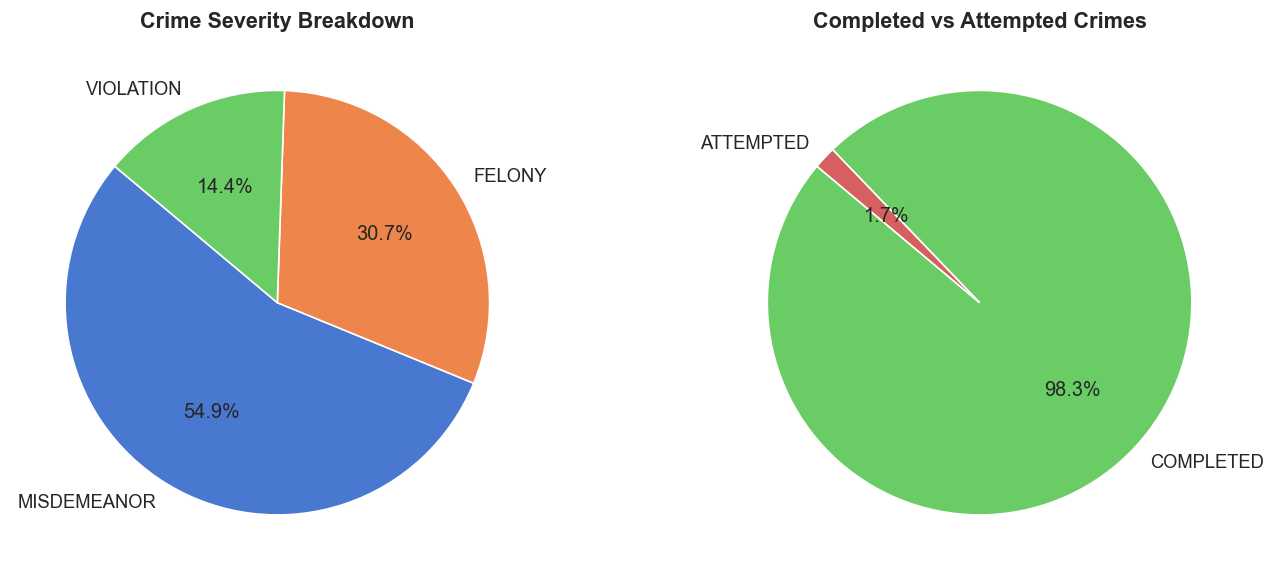

In [6]:
#Felony/Misdemeanor/Violation split
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

law_counts = df['LAW_CAT_CD'].value_counts()
axes[0].pie(law_counts, labels=law_counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=140, wedgeprops=dict(edgecolor='white'))
axes[0].set_title('Crime Severity Breakdown')

#Completed vs Attempted crimes
crm_counts = df['CRM_ATPT_CPTD_CD'].value_counts()
axes[1].pie(crm_counts, labels=crm_counts.index, autopct='%1.1f%%',
            colors=PALETTE[2:], startangle=140, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Completed vs Attempted Crimes')

plt.tight_layout()
plt.show()

C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\290895473.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='muted', ax=ax)


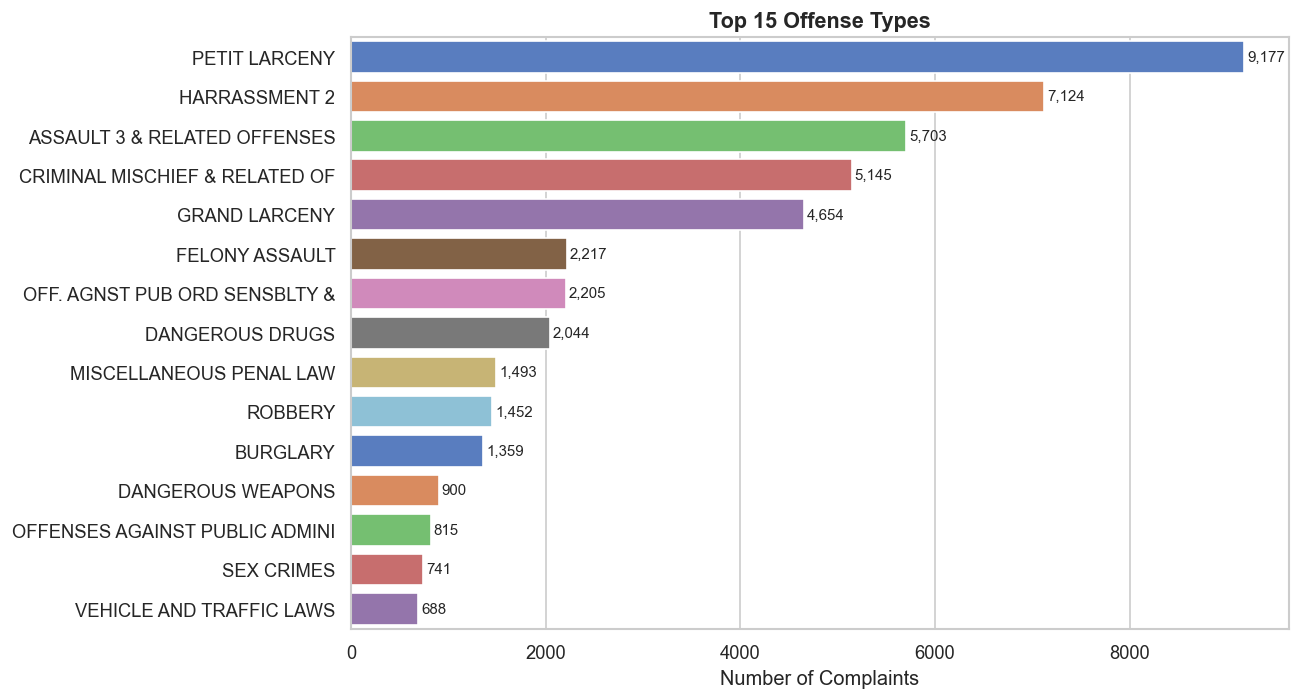

In [7]:
#Top 15 offense types
top15 = df['OFNS_DESC'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=top15.values, y=top15.index, palette='muted', ax=ax)
ax.set_title('Top 15 Offense Types')
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('')
for i, v in enumerate(top15.values):
    ax.text(v + 30, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

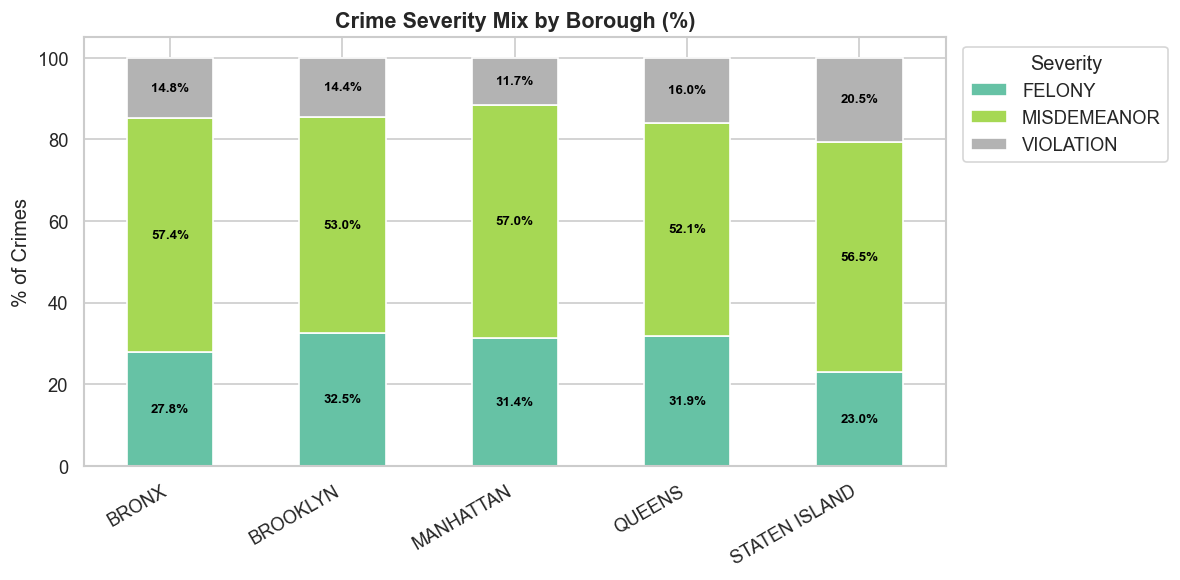

In [8]:
#Crime severity by borough
sev_boro = df.groupby(['BORO_NM','LAW_CAT_CD']).size().unstack(fill_value=0)
sev_boro_pct = sev_boro.div(sev_boro.sum(axis=1), axis=0) * 100

ax = sev_boro_pct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10,5), edgecolor='white')

for bar_stack in ax.containers:
    ax.bar_label(
        bar_stack,
        fmt='%.1f%%',      
        label_type='center',
        fontsize=8,
        fontweight='bold',
        color='black'
    )

plt.title('Crime Severity Mix by Borough (%)')
plt.xlabel('')
plt.ylabel('% of Crimes')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Severity', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()

## Time Analysis
Identifying when crimes peak is directly tied to predicting what times need extra police attention.

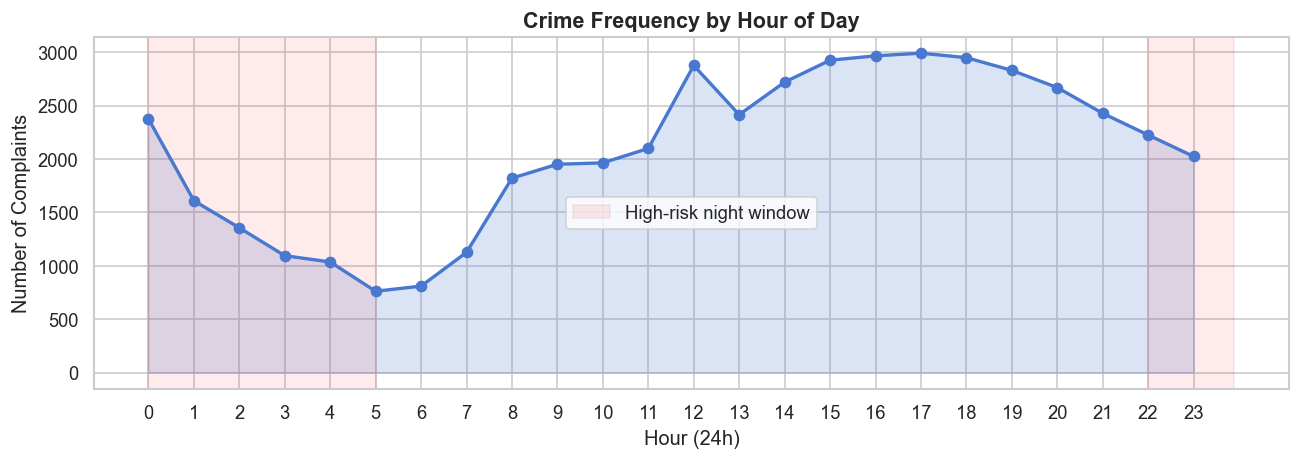

In [9]:
#Crimes by hour of day
hour_counts = df['HOUR'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, color=PALETTE[0])
ax.fill_between(hour_counts.index, hour_counts.values, alpha=0.2, color=PALETTE[0])
ax.set_title('Crime Frequency by Hour of Day')
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Number of Complaints')
ax.set_xticks(range(0, 24))
ax.axvspan(22, 23.9, alpha=0.08, color='red', label='High-risk night window')
ax.axvspan(0, 5, alpha=0.08, color='red')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\2358026043.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_counts.index, y=dow_counts.values, palette='muted', ax=ax)


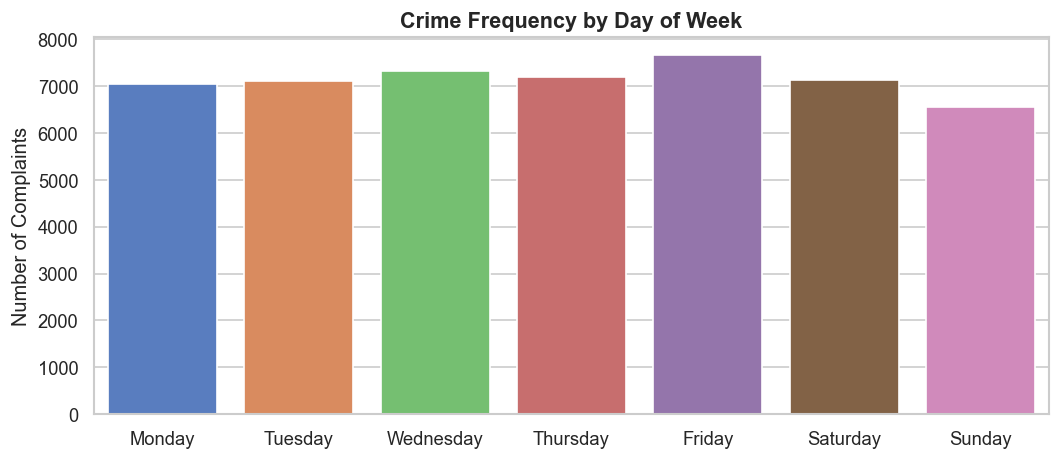

In [10]:
#Crimes by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df['DAY_OF_WEEK'].value_counts().reindex(dow_order)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=dow_counts.index, y=dow_counts.values, palette='muted', ax=ax)
ax.set_title('Crime Frequency by Day of Week')
ax.set_xlabel('')
ax.set_ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

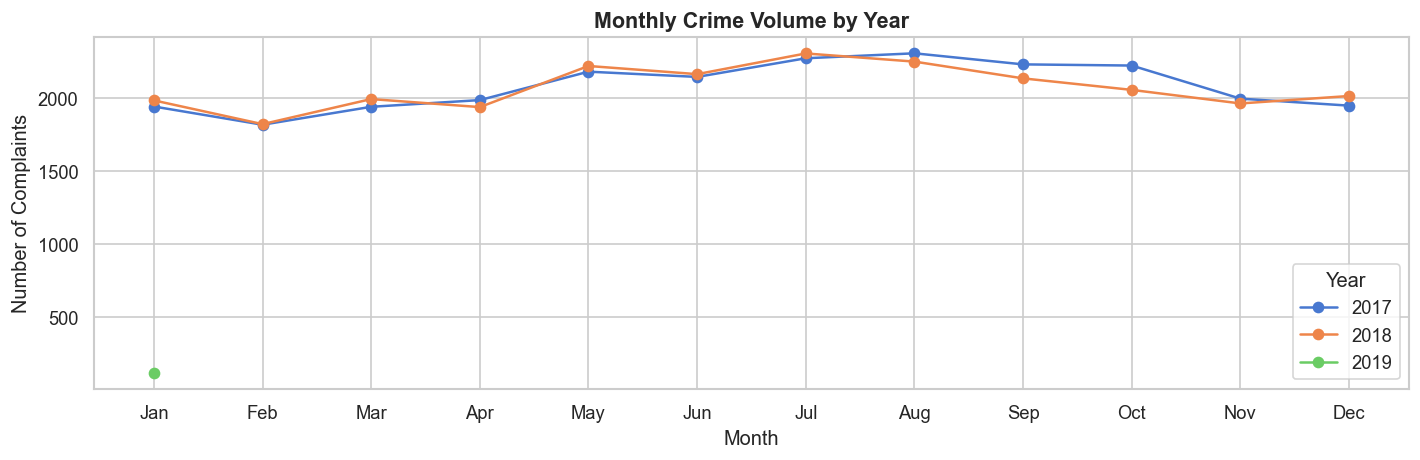

In [11]:
#Monthly trend
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby(['YEAR','MONTH_NAME']).size().reset_index(name='count')
monthly['MONTH_NAME'] = pd.Categorical(monthly['MONTH_NAME'], categories=month_order, ordered=True)
monthly = monthly.sort_values(['YEAR','MONTH_NAME'])

fig, ax = plt.subplots(figsize=(12, 4))
for yr, grp in monthly.groupby('YEAR'):
    ax.plot(grp['MONTH_NAME'].astype(str), grp['count'], marker='o', label=str(yr))
ax.set_title('Monthly Crime Volume by Year')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Complaints')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

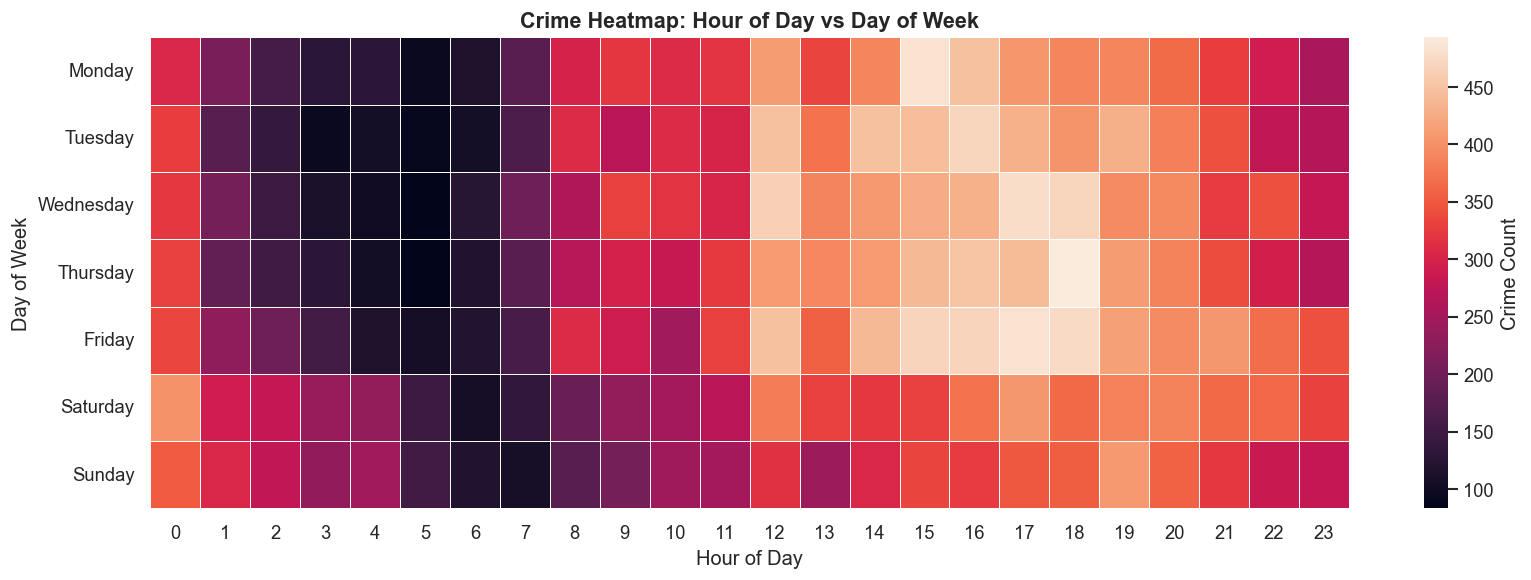

In [12]:
#Heatmap for hour vs day of week
pivot = df.groupby(['DAY_OF_WEEK','HOUR']).size().unstack(fill_value=0)
pivot = pivot.reindex(dow_order)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, linewidths=0.3, ax=ax, cbar_kws={'label':'Crime Count'})
ax.set_title('Crime Heatmap: Hour of Day vs Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\3983646137.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tod_sev = df.groupby(['TIME_OF_DAY','LAW_CAT_CD']).size().unstack(fill_value=0)


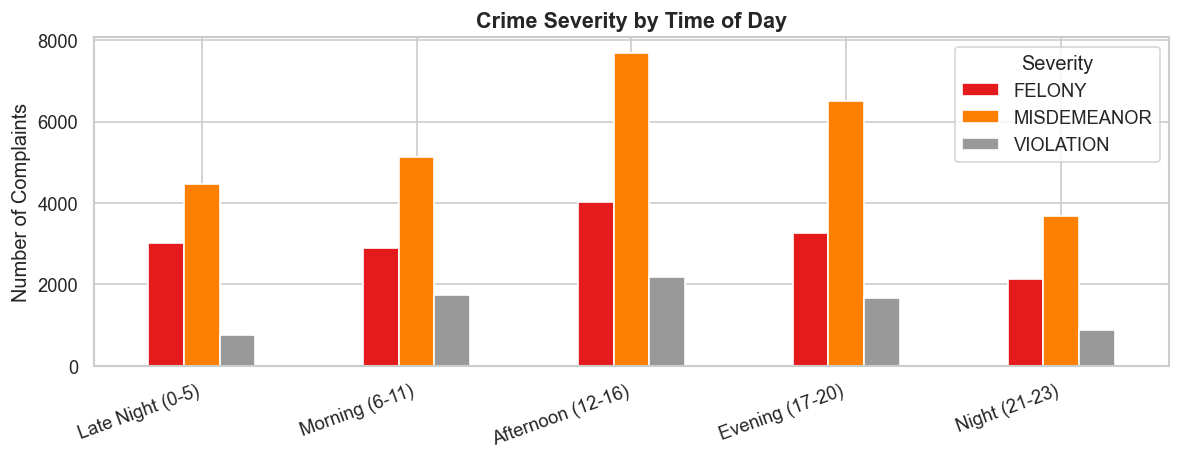

In [13]:
#Crime severity across time of day
tod_sev = df.groupby(['TIME_OF_DAY','LAW_CAT_CD']).size().unstack(fill_value=0)
tod_sev.plot(kind='bar', stacked=False, colormap='Set1', figsize=(10,4), edgecolor='white')
plt.title('Crime Severity by Time of Day')
plt.xlabel('')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Severity')
plt.tight_layout()
plt.show()

## Geographic & Borough Analysis
Understanding the geographic distribution of crime reports helps define patrol allocation, determining which boroughs and patrol divisions carry the highest burden, and whether that burden is uniform across crime types

C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\2381389796.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=boro_counts.index, y=boro_counts.values, palette='muted', ax=ax)


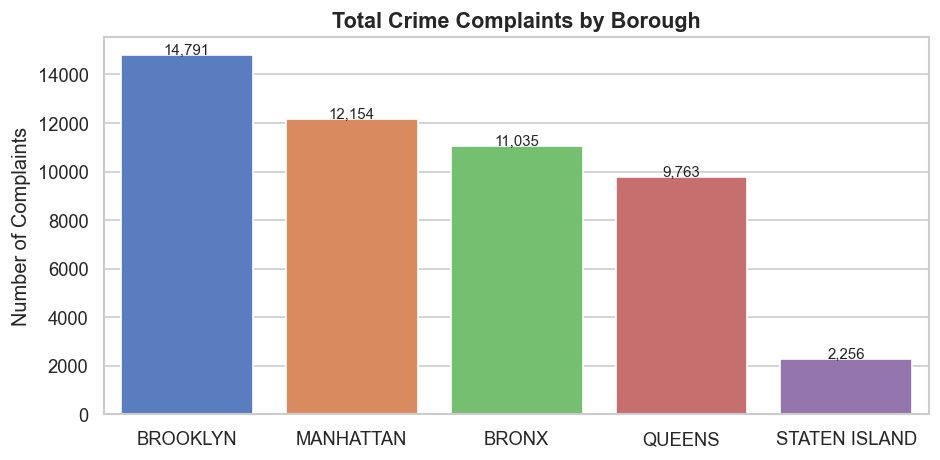

In [14]:
#Total complaints per borough
boro_counts = df['BORO_NM'].value_counts().dropna()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=boro_counts.index, y=boro_counts.values, palette='muted', ax=ax)
ax.set_title('Total Crime Complaints by Borough')
ax.set_ylabel('Number of Complaints')
ax.set_xlabel('')
for i, v in enumerate(boro_counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\1755844058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=patrol_counts.values, y=patrol_counts.index, palette='muted', ax=ax)


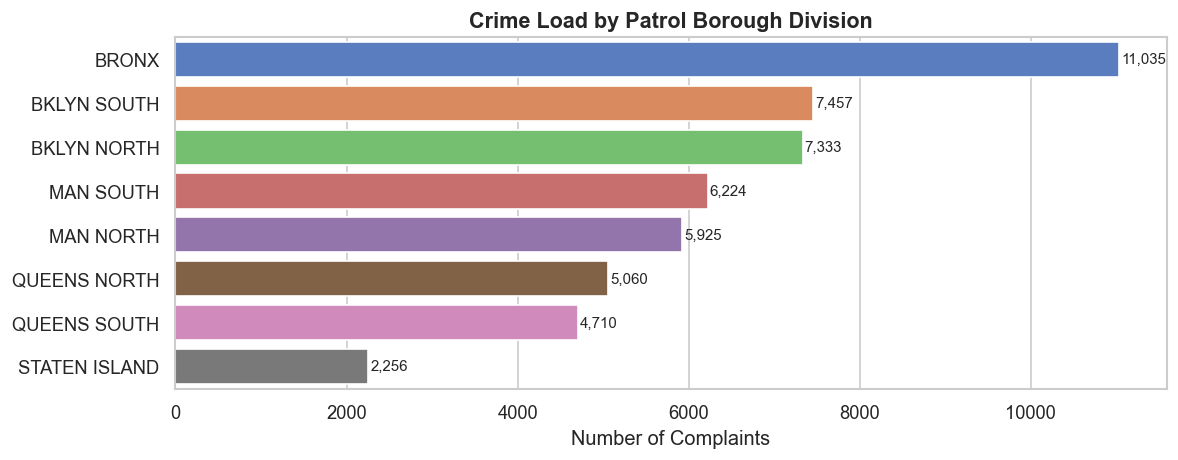

In [15]:
#Patrol borough load
patrol_counts = df['PATROL_BORO'].str.replace('PATROL BORO ', '', regex=False).value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=patrol_counts.values, y=patrol_counts.index, palette='muted', ax=ax)
ax.set_title('Crime Load by Patrol Borough Division')
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('')
for i, v in enumerate(patrol_counts.values):
    ax.text(v + 20, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [16]:
#Top offense per borough
top_offense_boro = (
    df.groupby(['BORO_NM','OFNS_DESC']).size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .groupby('BORO_NM').head(5)
)
display(top_offense_boro.pivot_table(index='OFNS_DESC', columns='BORO_NM', values='count', fill_value=0))

BORO_NM,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
OFNS_DESC,,,,,
ASSAULT 3 & RELATED OFFENSES,1547.0,1601.0,1165.0,1151.0,239.0
CRIMINAL MISCHIEF & RELATED OF,1139.0,1541.0,1044.0,1141.0,280.0
GRAND LARCENY,717.0,1258.0,1727.0,828.0,0.0
HARRASSMENT 2,1628.0,2091.0,1395.0,1548.0,462.0
OFF. AGNST PUB ORD SENSBLTY &,0.0,0.0,0.0,0.0,137.0
PETIT LARCENY,1690.0,2618.0,2881.0,1636.0,352.0


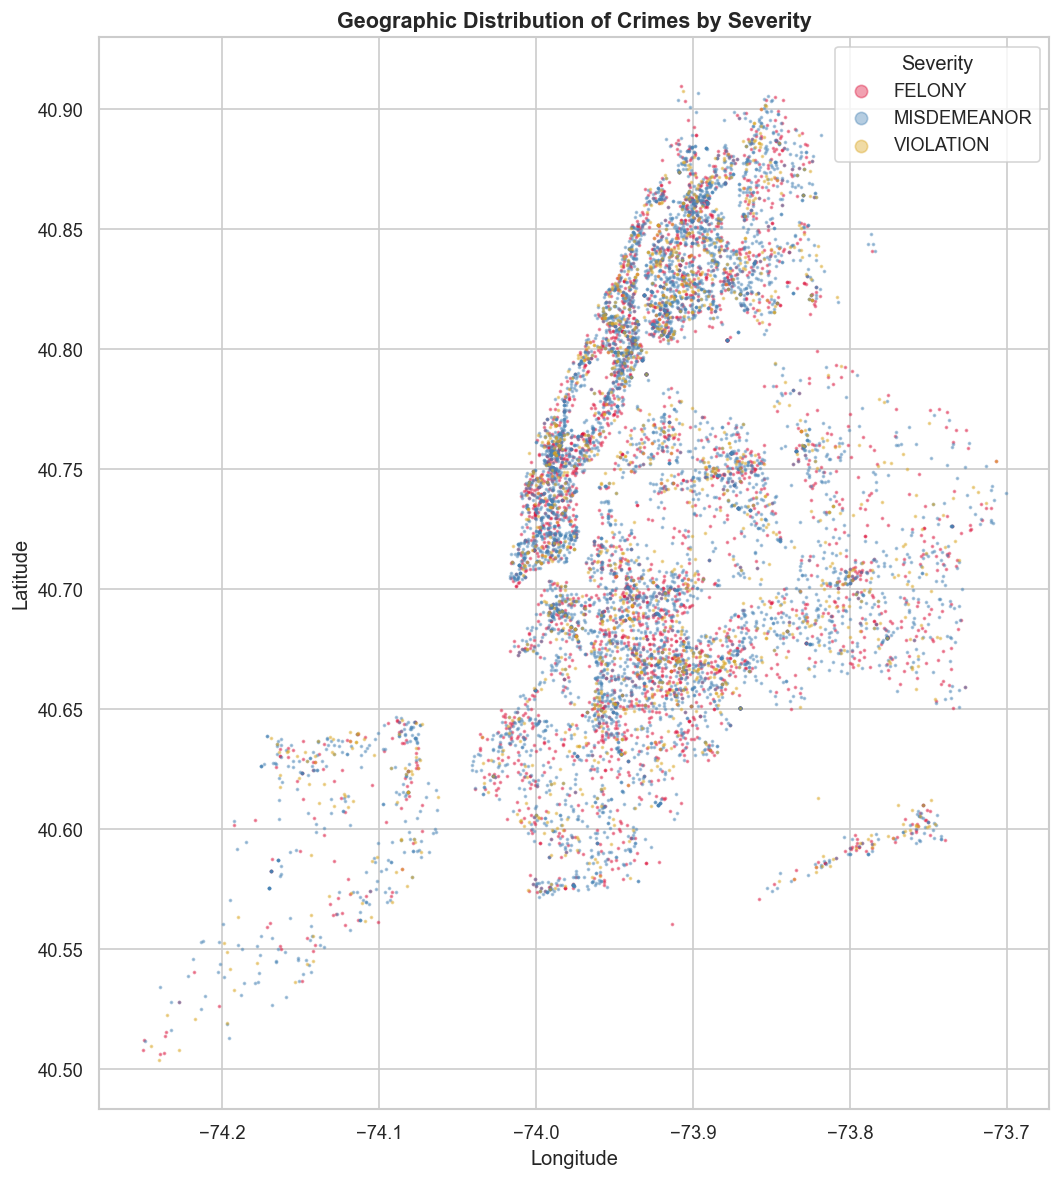

In [ ]:
#Geographic scatter plot of crimes (Latitude/Longitude)
sample = df[['Latitude','Longitude','LAW_CAT_CD']].dropna().sample(n=min(10000, len(df)), random_state=42)
palette_map = {'FELONY':'crimson','MISDEMEANOR':'steelblue','VIOLATION':'goldenrod'}
fig, ax = plt.subplots(figsize=(9, 10))
for cat, grp in sample.groupby('LAW_CAT_CD'):
    ax.scatter(grp['Longitude'], grp['Latitude'], s=1.5, alpha=0.4,
               color=palette_map.get(cat,'grey'), label=cat)
ax.set_title('Geographic Distribution of Crimes by Severity')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Severity', markerscale=6)
plt.tight_layout()
plt.show()

## Premise & Location Analysis
The PREM_TYP_DESC column describes where a crime occurred (street, apartment, subway, etc.). This is critical for the city improvement recommendations

C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\3684579939.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_prem.values, y=top_prem.index, palette='muted', ax=ax)


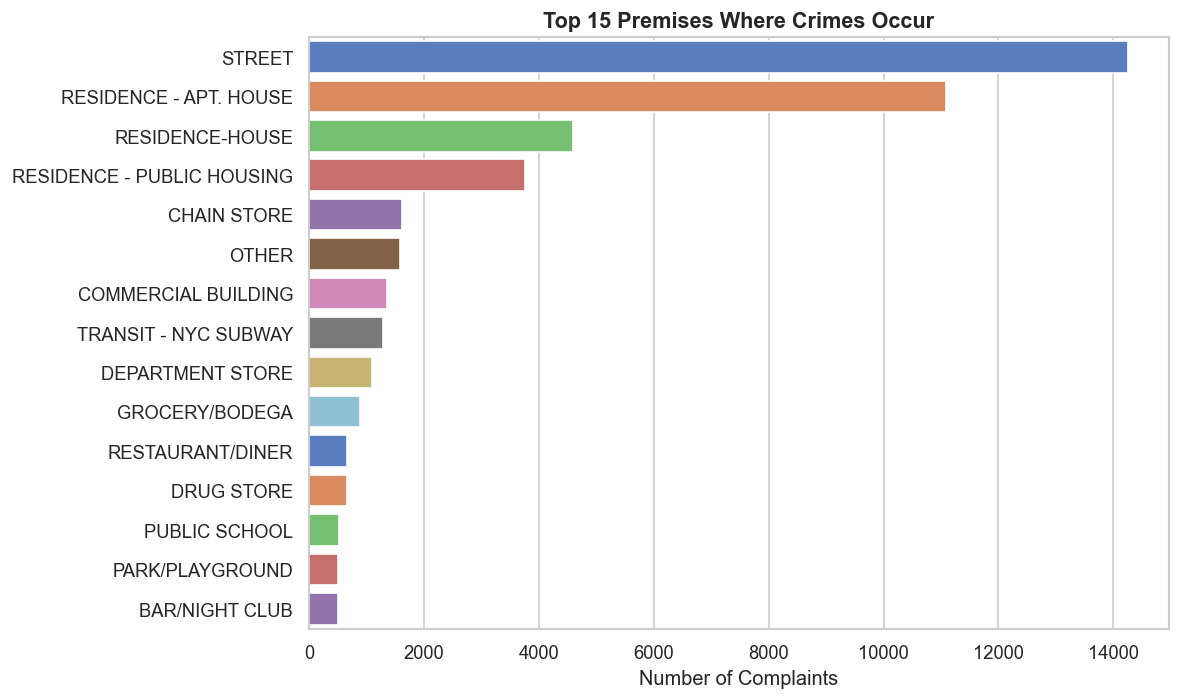

In [18]:
#Top 15 premises by crime count
top_prem = df['PREM_TYP_DESC'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_prem.values, y=top_prem.index, palette='muted', ax=ax)
ax.set_title('Top 15 Premises Where Crimes Occur')
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

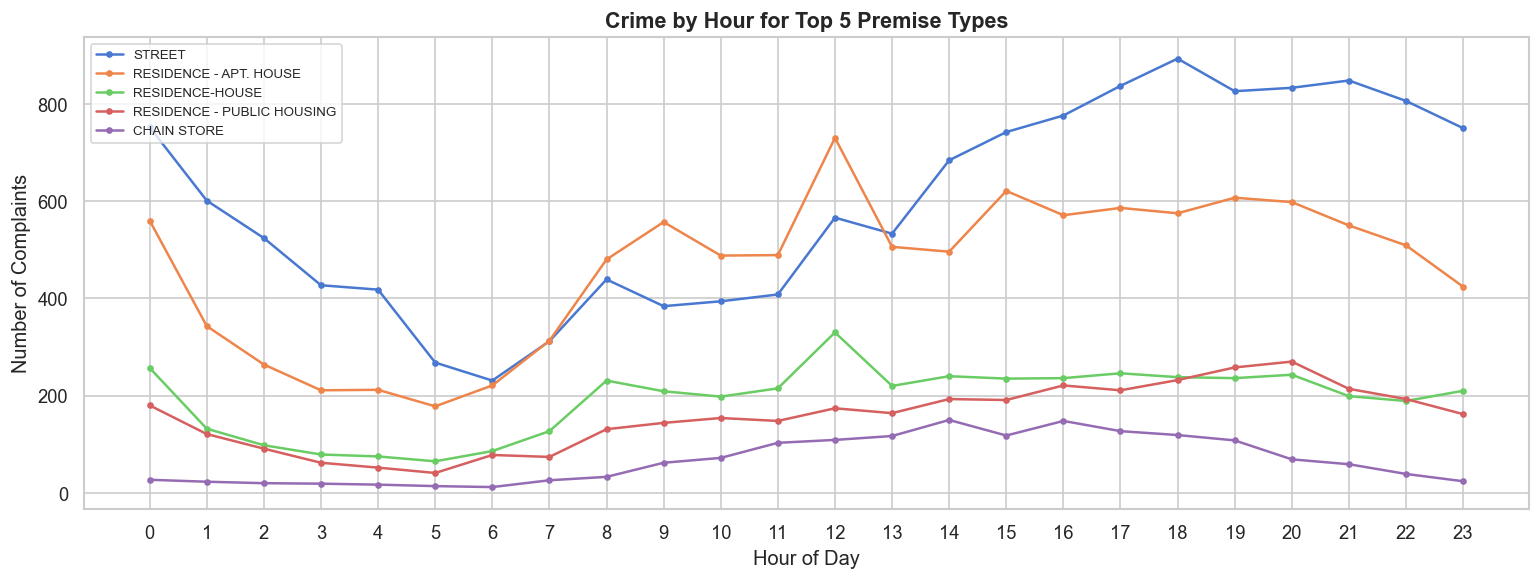

In [19]:
#Premise vs. time of day
top5_prem = df['PREM_TYP_DESC'].value_counts().head(5).index.tolist()
prem_tod = df[df['PREM_TYP_DESC'].isin(top5_prem)].groupby(['PREM_TYP_DESC','HOUR']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(13, 5))
for prem in top5_prem:
    ax.plot(prem_tod.columns, prem_tod.loc[prem], marker='.', label=prem)
ax.set_title('Crime by Hour for Top 5 Premise Types')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Complaints')
ax.set_xticks(range(0,24))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\3950490425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_counts.values, y=loc_counts.index, palette='pastel', ax=ax)


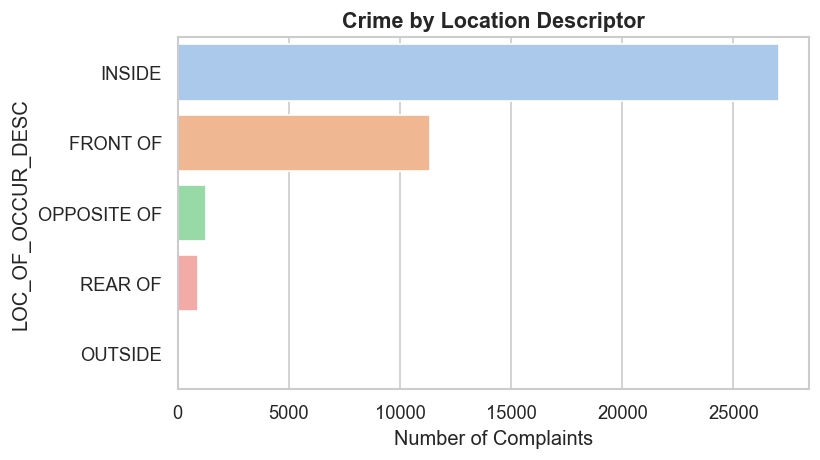

In [20]:
#Location of occurrence
loc_counts = df['LOC_OF_OCCUR_DESC'].value_counts().dropna()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=loc_counts.values, y=loc_counts.index, palette='pastel', ax=ax)
ax.set_title('Crime by Location Descriptor')
ax.set_xlabel('Number of Complaints')
plt.tight_layout()
plt.show()

## Suspect & Victim Demographics
Demographic patterns in suspects and victims can inform risk profiling.

C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\3257247479.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=ax)
C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\3257247479.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=ax)


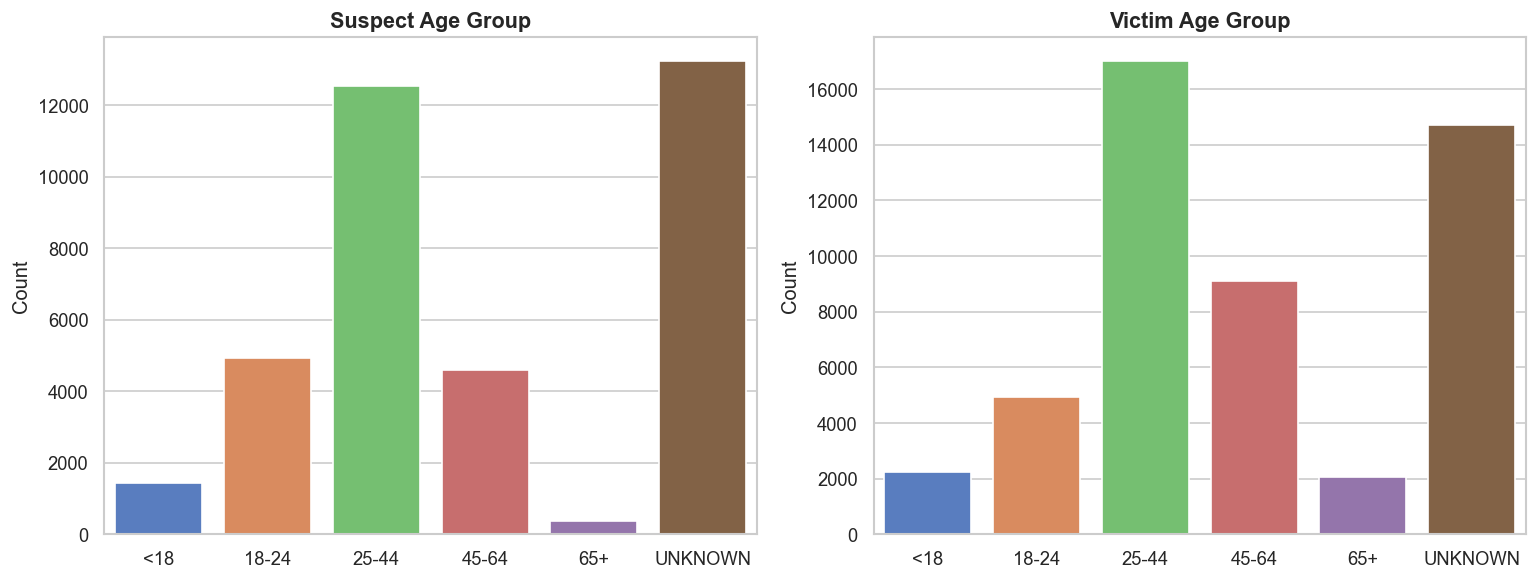

In [21]:
#Age group distributions for suspects vs victims
age_order = ['<18','18-24','25-44','45-64','65+','UNKNOWN']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes,
        ['SUSP_AGE_GROUP','VIC_AGE_GROUP'],
        ['Suspect Age Group','Victim Age Group']):
    counts = df[col].value_counts().reindex(age_order).dropna()
    sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

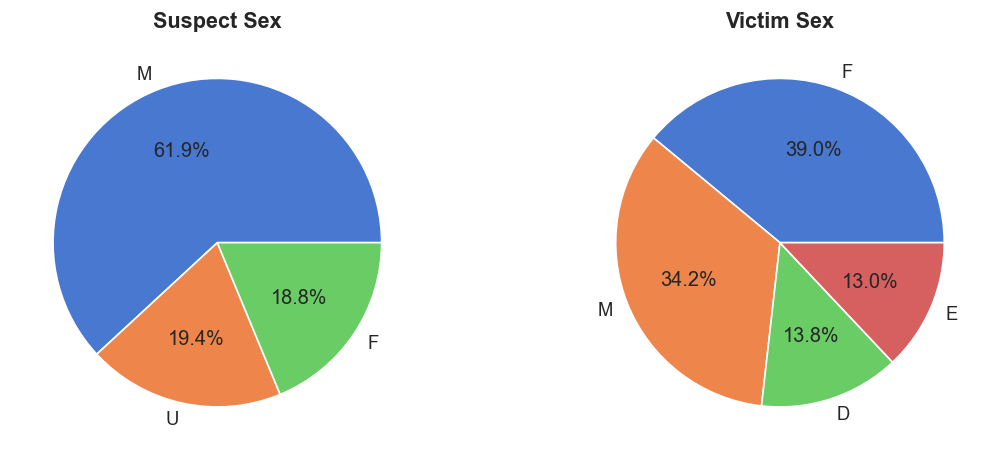

In [22]:
#Sex distribution for suspects vs victims
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(axes,
        ['SUSP_SEX','VIC_SEX'],
        ['Suspect Sex','Victim Sex']):
    counts = df[col].value_counts().dropna()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=PALETTE, wedgeprops=dict(edgecolor='white'))
    ax.set_title(title)
plt.tight_layout()
plt.show()

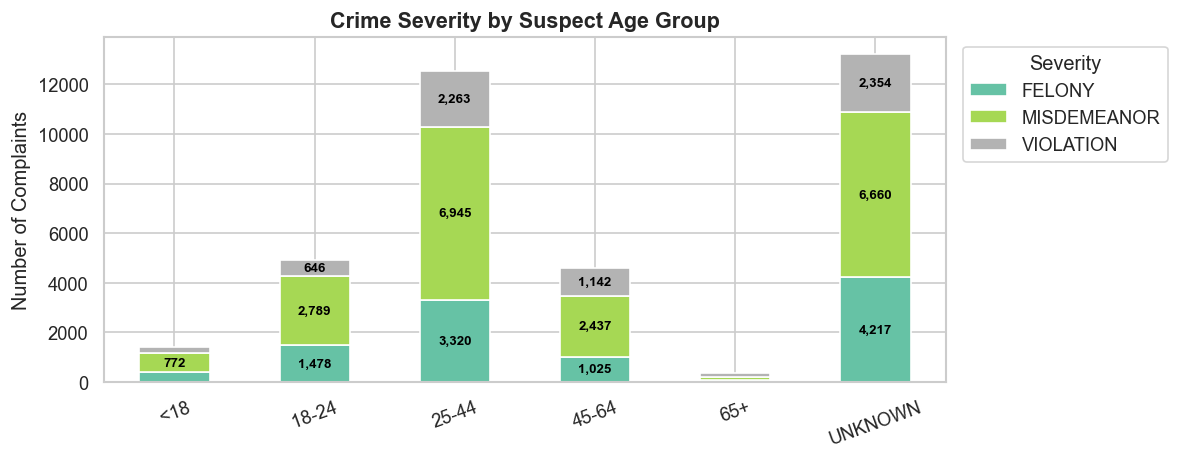

In [23]:
#Crime severity by suspect age group
susp_sev = df.groupby(['SUSP_AGE_GROUP','LAW_CAT_CD']).size().unstack(fill_value=0)
susp_sev = susp_sev.reindex([a for a in age_order if a in susp_sev.index])
ax = susp_sev.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10, 4), edgecolor='white')

for bar_stack in ax.containers:
    labels = [f'{int(v):,}' if v >= 500 else '' for v in bar_stack.datavalues]
    ax.bar_label(
        bar_stack,
        labels=labels,
        label_type='center',
        fontsize=8,
        fontweight='bold',
        color='black'
    )

plt.title('Crime Severity by Suspect Age Group')
plt.xlabel('')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=20)
plt.legend(title='Severity', bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.show()

## Correlation & Feature Relationship Analysis
It is useful to understand which features have predictive relationships with crime severity and frequency. This section examines feature interactions that indicate correlation or relatedness.

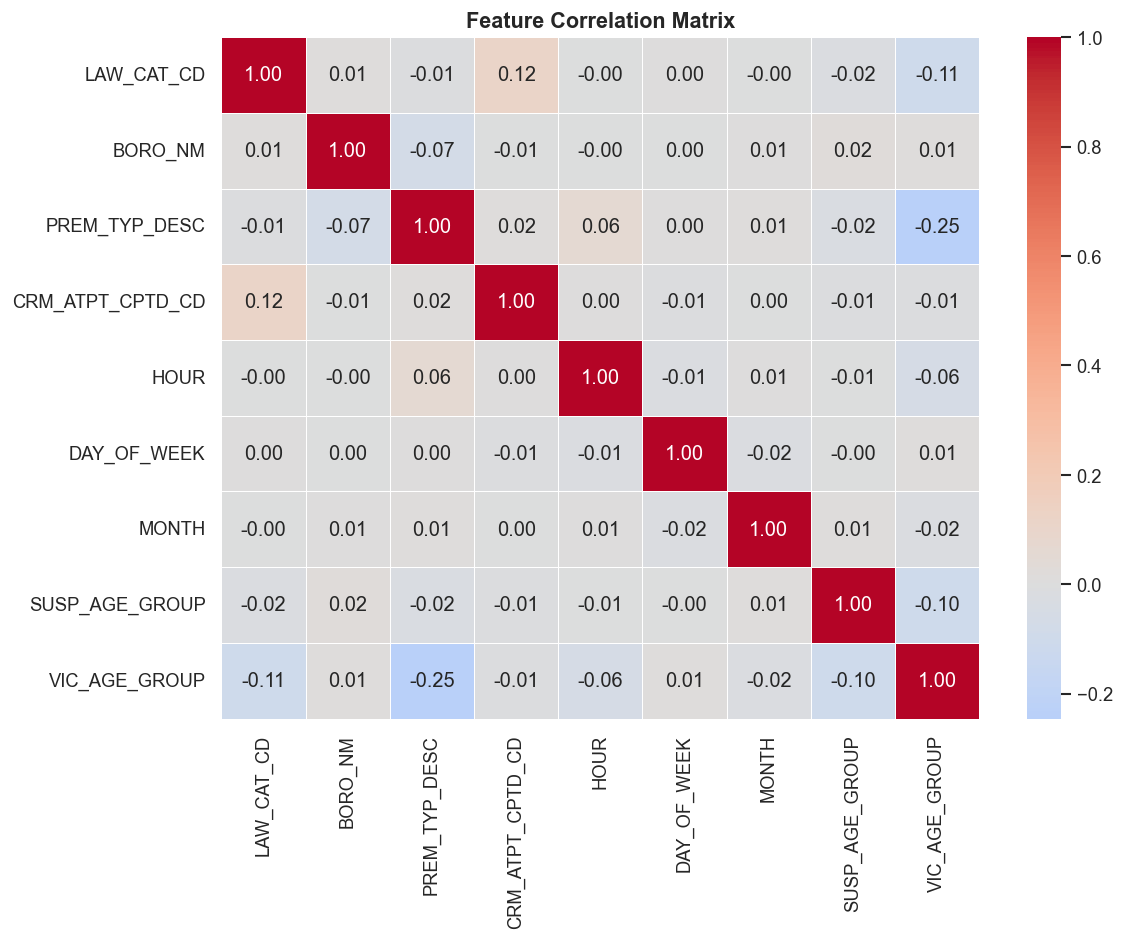

In [24]:
#Encode categoricals for correlation matrix
from sklearn.preprocessing import LabelEncoder

corr_cols = ['LAW_CAT_CD','BORO_NM','PREM_TYP_DESC','CRM_ATPT_CPTD_CD',
             'HOUR','DAY_OF_WEEK','MONTH','SUSP_AGE_GROUP','VIC_AGE_GROUP']
corr_df = df[corr_cols].copy().dropna()
le = LabelEncoder()
for col in corr_cols:
    corr_df[col] = le.fit_transform(corr_df[col].astype(str))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

C:\Users\Nicol\AppData\Local\Temp\ipykernel_12788\3619097685.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot2 = df.groupby(['BORO_NM','TIME_OF_DAY']).size().unstack(fill_value=0)


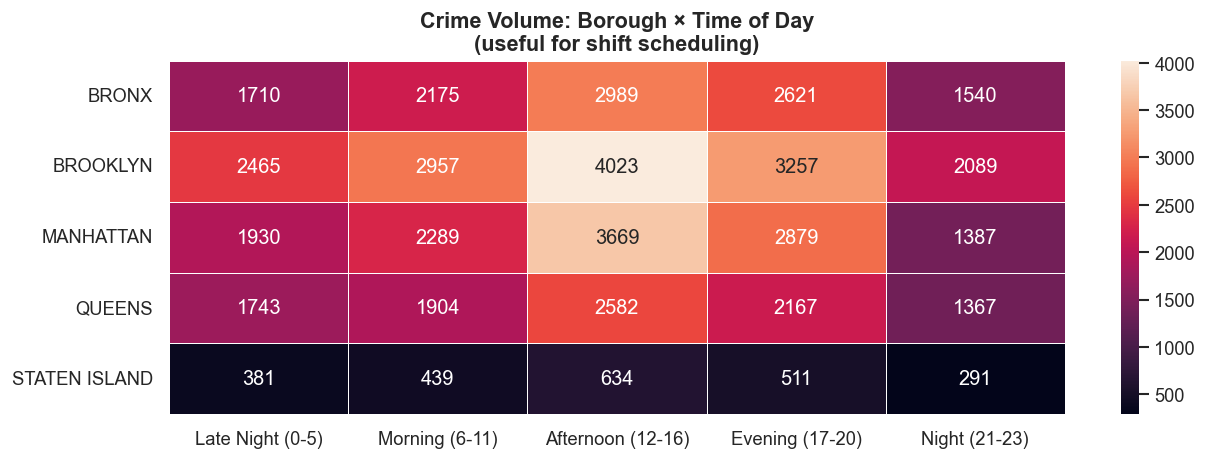

In [25]:
#Crime volume for Borough vs Time of Day
pivot2 = df.groupby(['BORO_NM','TIME_OF_DAY']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot2, annot=True, fmt='d', linewidths=0.4, ax=ax)
ax.set_title('Crime Volume: Borough × Time of Day\n(useful for shift scheduling)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

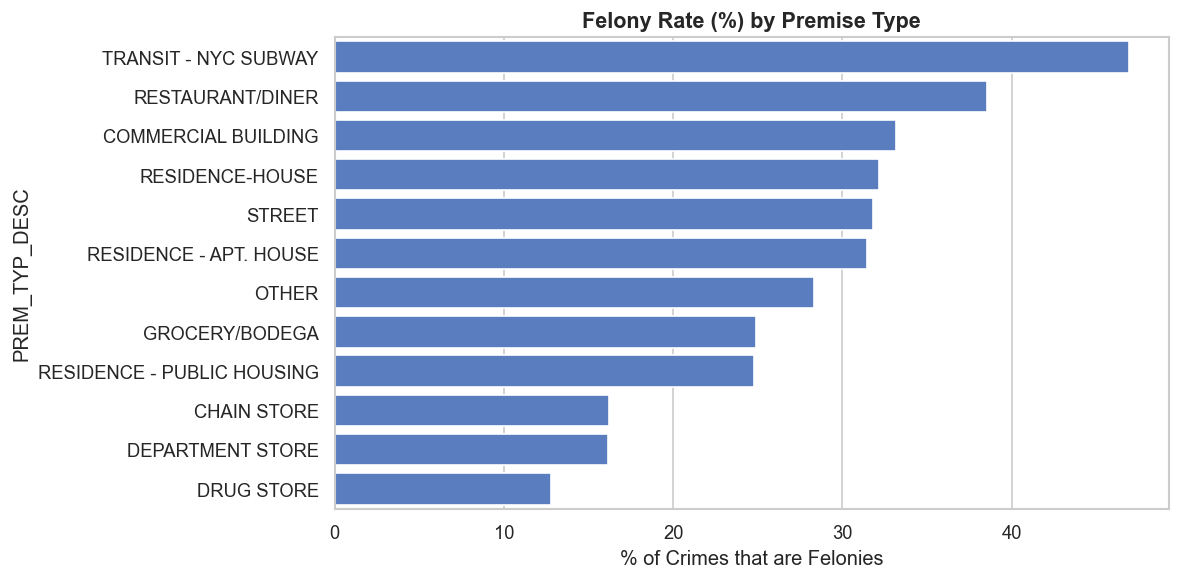

In [26]:
#Felony rate by premise type
top12_prem = df['PREM_TYP_DESC'].value_counts().head(12).index
prem_felony = (
    df[df['PREM_TYP_DESC'].isin(top12_prem)]
    .groupby('PREM_TYP_DESC')['LAW_CAT_CD']
    .apply(lambda x: (x == 'FELONY').mean() * 100)
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=prem_felony.values, y=prem_felony.index, ax=ax)
ax.set_title('Felony Rate (%) by Premise Type')
ax.set_xlabel('% of Crimes that are Felonies')
plt.tight_layout()
plt.show()